<a href="https://colab.research.google.com/github/OzWoody04/Elec5305-Project-520475506/blob/main/Final_Project_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Acoustics Final Project**
*Audio Fingerprinting and Deep Learning for Vehicle Sound Classification*
##### Alex Wood


## Setup

Using Kaggle dataset atm. Install required libraries and import common modules.  This cell only needs to be run once at the start of the notebook.


All audio is converted to a consistent format:
- 22.05 kHz sample rate
- Mono
- Normalised amplitude

We then build `manifest.csv` containing the path and label for each clip.

In [1]:
!pip -q install kagglehub librosa==0.10.2.post1 soundfile pandas numpy tqdm scikit-learn==1.5.1 matplotlib gradio==4.44.0 torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu
import kagglehub, os, glob, pandas as pd, numpy as np, librosa, soundfile as sf
from tqdm import tqdm

DATASET_ID = "janboubiabderrahim/vehicle-sounds-dataset"
RAW_DIR = kagglehub.dataset_download(DATASET_ID)
print("Downloaded to:", RAW_DIR)

import os, glob

PROC_DIR = "/content/data_processed"
SR = 22050
os.makedirs(PROC_DIR, exist_ok=True)

KNOWN_LABELS = {'bus','train','airplane','bics','motocycles','helicopter','truck','cars'}  # dataset’s own labels

def guess_label(path: str) -> str:
    # parent folder name (dataset is class-per-folder)
    p = os.path.basename(os.path.dirname(path)).lower()
    return p if p in KNOWN_LABELS else 'unknown'

def to_wav(src_path: str, dst_path: str, sr: int = SR):
    y, sr = librosa.load(src_path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    sf.write(dst_path, y, sr)

audio_exts = ('.wav','.mp3','.flac','.m4a','.ogg','.au','.aiff','.aif')
files = [p for p in glob.glob(os.path.join(RAW_DIR, '**', '*'), recursive=True)
         if os.path.isfile(p) and p.lower().endswith(audio_exts)]

rows, skipped = [], 0
for i, src in enumerate(tqdm(files, desc='Preprocessing → WAV 22.05 kHz mono')):
    lab = guess_label(src)
    if lab == 'unknown':
        skipped += 1
        continue
    out = os.path.join(PROC_DIR, f"{i:06d}_{lab}.wav")
    try:
        to_wav(src, out)
        rows.append({'track_id': i, 'path': out, 'label': lab})
    except Exception as e:
        skipped += 1

manifest = pd.DataFrame(rows).reset_index(drop=True)
manifest_path = "/content/manifest.csv"
manifest.to_csv(manifest_path, index=False)

print("Summary")
print("Raw files:", len(files), "| kept:", len(manifest), "| skipped:", skipped)
print("Class counts:\n", manifest['label'].value_counts())



ERROR: Operation cancelled by user


100%|██████████| 6.90G/6.90G [05:34<00:00, 22.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/janboubiabderrahim/vehicle-sounds-dataset/versions/1


Preprocessing → WAV 22.05 kHz mono: 100%|██████████| 9448/9448 [02:58<00:00, 53.01it/s]

Summary
Raw files: 9448 | kept: 9448 | skipped: 0
Class counts:
 label
bus           4221
train         2552
airplane       673
bics           617
motocycles     537
helicopter     353
truck          265
cars           230
Name: count, dtype: int64


# Set Training




### Splitting - We collapse the original labels into a binary problem


In [3]:
from sklearn.model_selection import train_test_split

mf = pd.read_csv("/content/manifest.csv")

POS = "cars"
NEG_CANDIDATES = ["bus","truck","train","motocycles","helicopter","airplane","bics"]

pos_df = mf[mf["label"]==POS]
neg_df = mf[mf["label"].isin(NEG_CANDIDATES)]

# Balance: take up to 2× negatives vs positives (tweak if you like)
neg_take = min(len(neg_df), len(pos_df)*2 if len(pos_df) else len(neg_df))
neg_df = neg_df.sample(n=neg_take, random_state=42)

bin_df = pd.concat([pos_df, neg_df]).reset_index(drop=True)
bin_df["label"] = bin_df["label"].apply(lambda x: "car" if x==POS else "not_car")

train_df, test_df = train_test_split(bin_df, test_size=0.2, stratify=bin_df["label"], random_state=42)

train_df.to_csv("/content/manifest_car_train.csv", index=False)
test_df.to_csv("/content/manifest_car_test.csv", index=False)

train_df["label"].value_counts(), test_df["label"].value_counts()


(label
 not_car    368
 car        184
 Name: count, dtype: int64,
 label
 not_car    92
 car        46
 Name: count, dtype: int64)

### Building Paths

This branch implements a Shazam-like lookup:

1. Compute STFT and find local spectral peaks (constellation map).
2. Form hash pairs `(f1, f2, Δt)` around each anchor peak.
3. Store all hashes in an SQLite database.
4. At query time, match hashes and find the track with the most consistent time offset.

In [2]:
import sqlite3, numpy as np
from scipy.ndimage import maximum_filter

DB_PATH = "/content/fp_car.sqlite"

def ensure_schema(db_path=DB_PATH):
    con = sqlite3.connect(db_path); cur = con.cursor()
    cur.execute("CREATE TABLE IF NOT EXISTS tracks(track_id INTEGER PRIMARY KEY, label TEXT, path TEXT)")
    cur.execute("CREATE TABLE IF NOT EXISTS hashes(hash INTEGER, track_id INTEGER, t_anchor INTEGER)")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_hash ON hashes(hash)")
    cur.execute("CREATE INDEX IF NOT EXISTS idx_track ON hashes(track_id, t_anchor)")
    con.commit(); con.close()

def spectrogram_peaks(y, sr, n_fft=2048, hop=512, top_k_per_frame=5,
                      fmin=50, fmax=None, neighborhood=(20, 10)):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    if fmax is None: fmax = freqs[-1]
    band = (freqs >= fmin) & (freqs <= fmax)
    S_band = S[band]
    mx = maximum_filter(S_band, size=neighborhood, mode='constant')
    peaks_mask = (S_band == mx) & (S_band > np.median(S_band))
    peaks = []
    band_start = np.where(band)[0][0]
    for t in range(peaks_mask.shape[1]):
        idx = np.where(peaks_mask[:, t])[0]
        if idx.size:
            mags = S_band[idx, t]
            keep = idx[np.argsort(mags)[-top_k_per_frame:]]
            for fi in keep:
                peaks.append((band_start + fi, t))
    return np.array(peaks, dtype=int)

def make_hashes(peaks, fan_out=5, min_dt=1, max_dt=80):
    hashes = []
    for i in range(len(peaks)):
        f1, t1 = peaks[i]
        for j in range(1, fan_out+1):
            if i + j >= len(peaks): break
            f2, t2 = peaks[i+j]
            dt = t2 - t1
            if min_dt <= dt <= max_dt:
                h = (int(f1) & 0x3FF) << 22 | (int(f2) & 0x3FF) << 12 | (int(dt) & 0xFFF)
                hashes.append((h, t1))
    return hashes

def audio_to_hashes(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    peaks = spectrogram_peaks(y, sr)
    return make_hashes(peaks)

def build_fp_db(manifest_csv, db_path=DB_PATH):
    ensure_schema(db_path)
    df = pd.read_csv(manifest_csv)
    con = sqlite3.connect(db_path)
    for _, r in tqdm(df.iterrows(), total=len(df), desc="Indexing FP DB"):
        con.execute("INSERT OR REPLACE INTO tracks(track_id,label,path) VALUES(?,?,?)",
                    (int(r.track_id), r.label, r.path))
        hs = audio_to_hashes(r.path)
        if hs:
            con.executemany("INSERT INTO hashes(hash,track_id,t_anchor) VALUES(?,?,?)",
                            [(int(h), int(r.track_id), int(t)) for (h,t) in hs])
    con.commit(); con.close()

def query_fp(db_path, wav_path, min_matches=20):
    q = audio_to_hashes(wav_path)
    if not q: return {'status':'nohash'}
    q_times = {}
    for h,t in q:
        if h not in q_times: q_times[h] = t
    hs = list(q_times.keys())

    con = sqlite3.connect(db_path); cur = con.cursor()
    matches = []
    CHUNK = 800
    for i in range(0, len(hs), CHUNK):
        part = hs[i:i+CHUNK]
        cur.execute(f"SELECT hash, track_id, t_anchor FROM hashes WHERE hash IN ({','.join(['?']*len(part))})", part)
        for h, tid, t_anchor in cur.fetchall():
            matches.append((tid, t_anchor - q_times[h]))
    con.close()

    if len(matches) < min_matches: return {'status':'low', 'matches': len(matches)}

    from collections import defaultdict, Counter
    offsets_by_tid = defaultdict(list)
    for tid, off in matches:
        offsets_by_tid[tid].append(off)
    scores = {tid: Counter(ofs).most_common(1)[0][1] for tid, ofs in offsets_by_tid.items()}
    best_tid = max(scores, key=scores.get)

    con = sqlite3.connect(db_path)
    lab = pd.read_sql_query(f"SELECT label FROM tracks WHERE track_id={best_tid}", con).iloc[0]['label']
    con.close()
    # Map to binary label
    return {'status':'ok', 'label': 'car' if lab=='car' else lab}


In [4]:
build_fp_db("/content/manifest_car_train.csv")


Indexing FP DB: 100%|██████████| 552/552 [00:34<00:00, 15.99it/s]


### CNN Classification Branch - This branch learns to classify `car` vs `not_car` from Mel-spectrograms:

In [5]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random

# Mel-spec extraction
def melspec(path, sr=SR, n_mels=128, n_fft=2048, hop=512):
    y, sr = librosa.load(path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop)
    M = librosa.power_to_db(M, ref=np.max)
    return M.astype(np.float32)

class AudioDS(Dataset):
    def __init__(self, df, label_map={'car':1,'not_car':0}):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        M = melspec(row['path'])
        # crop/pad to fixed time length
        T = 256
        if M.shape[1] < T:
            pad = T - M.shape[1]
            M = np.pad(M, ((0,0),(0,pad)))
        else:
            start = 0 if M.shape[1]==T else random.randint(0, M.shape[1]-T)
            M = M[:, start:start+T]
        x = torch.from_numpy(M).unsqueeze(0)  # [1, n_mels, T]
        y = torch.tensor(self.label_map[row['label']], dtype=torch.long)
        return x, y

class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return self.head(x)

train_df = pd.read_csv("/content/manifest_car_train.csv")
test_df  = pd.read_csv("/content/manifest_car_test.csv")

train_ds = AudioDS(train_df); test_ds = AudioDS(test_df)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

device = torch.device('cpu')  # GPU will be used automatically in Colab if available
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(5):  # a few quick epochs; increase if you want
    model.train()
    tot, correct, n = 0.0, 0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y); loss.backward(); opt.step()
        tot += float(loss)
        preds = out.argmax(1)
        correct += int((preds==y).sum()); n += y.numel()
    print(f"Epoch {epoch+1}: loss={tot/len(train_dl):.4f}, train_acc={correct/n:.3f}")

# quick test accuracy
model.eval()
correct, n = 0, 0
with torch.no_grad():
    for x,y in test_dl:
        x,y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(1)
        correct += int((preds==y).sum()); n += y.numel()
print(f"CNN test accuracy: {correct/n:.3f}")


/tmp/ipython-input-4205407152.py:71: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  tot += float(loss)


Epoch 1: loss=0.7628, train_acc=0.560
Epoch 2: loss=0.6282, train_acc=0.667
Epoch 3: loss=0.6289, train_acc=0.667
Epoch 4: loss=0.6248, train_acc=0.667
Epoch 5: loss=0.6011, train_acc=0.667
CNN test accuracy: 0.667


### Hybrid Decision: Fingerprint First, CNN Fallback

We combine both branches:

- If the fingerprint score is high enough, use the fingerprint label.
- Otherwise, fall back to the CNN probability \(P(\text{car})\).

In [6]:
from sklearn.preprocessing import LabelEncoder

# convenience: function that returns 'car'/'not_car'
def cnn_predict_label(path):
    model.eval()
    M = melspec(path)
    T = 256
    if M.shape[1] < T:
        M = np.pad(M, ((0,0),(0,T-M.shape[1])))
    else:
        M = M[:, :T]
    x = torch.from_numpy(M).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        p = model(x).softmax(1).cpu().numpy()[0]
    return 'car' if p[1] >= p[0] else 'not_car', float(p[1])

def hybrid_predict(path, fp_db=DB_PATH, fp_min=20, fp_conf_threshold=30):
    fp = query_fp(fp_db, path, min_matches=fp_min)
    if fp.get('status')=='ok':
        # if we wanted to enforce a strength threshold, we'd add score; here we only have label
        return {'method':'fingerprint', 'label': fp['label']}
    # fallback to CNN
    lab, prob_car = cnn_predict_label(path)
    return {'method':'cnn', 'label': lab, 'prob_car': prob_car}

# quick sanity check on a few test files
sample = test_df.sample(5, random_state=0)['path'].tolist()
[ (os.path.basename(p), hybrid_predict(p)) for p in sample ]


[('001631_truck.wav', {'method': 'fingerprint', 'label': 'not_car'}),
 ('003214_train.wav', {'method': 'fingerprint', 'label': 'not_car'}),
 ('006072_bus.wav', {'method': 'fingerprint', 'label': 'not_car'}),
 ('000879_helicopter.wav', {'method': 'fingerprint', 'label': 'not_car'}),
 ('008123_bus.wav', {'method': 'fingerprint', 'label': 'not_car'})]

Hybrid Acc.

In [7]:
y_true, y_pred = [], []
for p, lab in zip(test_df['path'], test_df['label']):
    pred = hybrid_predict(p)['label']
    y_true.append(lab); y_pred.append(pred)

acc = np.mean([t==p for t,p in zip(y_true,y_pred)])
print(f"Hybrid accuracy (car vs not_car): {acc*100:.2f}% on {len(test_df)} clips")


Hybrid accuracy (car vs not_car): 67.39% on 138 clips


# Visualisation for testing

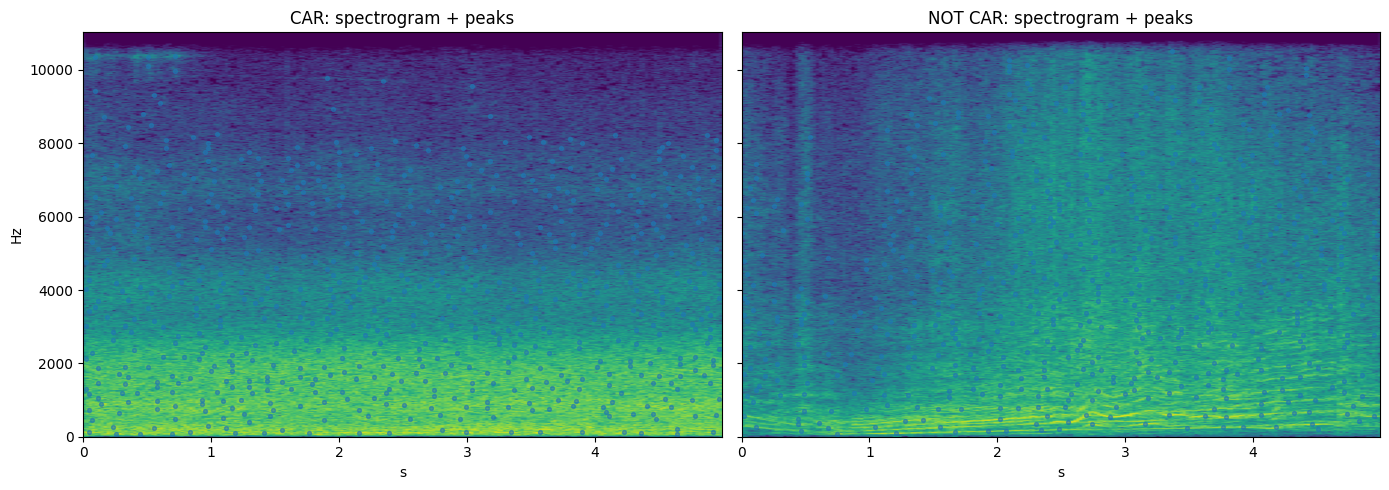

In [8]:
# (a) car vs not_car spectrograms with constellation peaks
import matplotlib.pyplot as plt

def compute_spec_and_peaks(path, sr=SR, n_fft=2048, hop=512):
    y, sr = librosa.load(path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    times = librosa.frames_to_time(np.arange(S.shape[1]), sr=sr, hop_length=hop)
    peaks = spectrogram_peaks(y, sr, n_fft=n_fft, hop=hop)
    if len(peaks)==0:
        f_vals, t_vals = np.array([]), np.array([])
    else:
        f_vals = freqs[peaks[:,0]]; t_vals = times[peaks[:,1]]
    return S_db, freqs, times, f_vals, t_vals

car_ex = test_df.query("label=='car'").sample(1, random_state=1).iloc[0]['path']
nc_ex  = test_df.query("label=='not_car'").sample(1, random_state=2).iloc[0]['path']

S1,f1,t1,pf1,pt1 = compute_spec_and_peaks(car_ex)
S2,f2,t2,pf2,pt2 = compute_spec_and_peaks(nc_ex)

fig, ax = plt.subplots(1,2, figsize=(14,5), sharey=True)
ax[0].imshow(S1, origin='lower', aspect='auto', extent=[t1[0], t1[-1], f1[0], f1[-1]])
ax[0].scatter(pt1, pf1, s=8, alpha=0.6)
ax[0].set_title("CAR: spectrogram + peaks"); ax[0].set_xlabel("s"); ax[0].set_ylabel("Hz")
ax[1].imshow(S2, origin='lower', aspect='auto', extent=[t2[0], t2[-1], f2[0], f2[-1]])
ax[1].scatter(pt2, pf2, s=8, alpha=0.6)
ax[1].set_title("NOT CAR: spectrogram + peaks"); ax[1].set_xlabel("s")
plt.tight_layout(); plt.show()


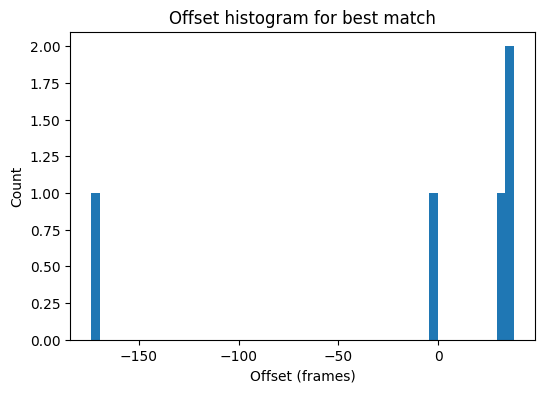

In [9]:
# (b) Offset consistency histogram for one query
import sqlite3
from collections import defaultdict, Counter

def query_with_offsets(db_path, wav_path, min_matches=10):
    q = audio_to_hashes(wav_path)
    if not q: return None, None
    q_times = {h:t for h,t in q}
    hs = list(q_times.keys())
    con = sqlite3.connect(db_path); cur = con.cursor()
    matches = []
    CHUNK=800
    for i in range(0, len(hs), CHUNK):
        part = hs[i:i+CHUNK]
        cur.execute(f"SELECT hash,track_id,t_anchor FROM hashes WHERE hash IN ({','.join(['?']*len(part))})", part)
        for h, tid, t_anchor in cur.fetchall():
            matches.append((tid, t_anchor - q_times[h]))
    con.close()
    if len(matches) < min_matches: return None, None
    buckets = defaultdict(list)
    for tid, off in matches: buckets[tid].append(off)
    best_tid = max(buckets, key=lambda k: Counter(buckets[k]).most_common(1)[0][1])
    return best_tid, np.array(buckets[best_tid])

ex = test_df.sample(1, random_state=9).iloc[0]['path']
tid, offs = query_with_offsets(DB_PATH, ex)
if offs is not None:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.hist(offs, bins=50)
    plt.title("Offset histogram for best match")
    plt.xlabel("Offset (frames)"); plt.ylabel("Count")
    plt.show()


# Web Demo with Streamlit

A simple Streamlit app allows uploading an audio file and running the hybrid classifier.  
In Colab this is mainly for demonstration; locally it can be deployed as a web app.

In [10]:
!pip -q install streamlit==1.39.0 pyngrok==7.2.0

# save your trained CNN from the previous cell
import torch, os
os.makedirs("/content/artifacts", exist_ok=True)
CNN_PATH = "/content/artifacts/cnn_car_notcar.pt"
torch.save(model.state_dict(), CNN_PATH)
print("Saved CNN to:", CNN_PATH)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.17.0 requires watchdog<7.0.0,>=6.0.0, but you have watchdog 5.0.3 which is incompatible.
Saved CNN to: /content/artifacts/cnn_car_notcar.pt


In [11]:
!pip -q install "websockets>=15,<16" "watchdog>=6,<7"  # satisfies google-adk & dataproc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.39.0 requires watchdog<6,>=2.1.5; platform_system != "Darwin", but you have watchdog 6.0.0 which is incompatible.


In [12]:
%%writefile app.py
import os, sqlite3, numpy as np, pandas as pd, librosa, torch, torch.nn as nn
from collections import defaultdict, Counter
import streamlit as st
from scipy.ndimage import maximum_filter

DB_PATH = "/content/fp_car.sqlite"
CNN_PATH = "/content/artifacts/cnn_car_notcar.pt"
SR = 22050

def spectrogram_peaks(y, sr, n_fft=2048, hop=512, top_k_per_frame=5,
                      fmin=50, fmax=None, neighborhood=(20, 10)):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    if fmax is None: fmax = freqs[-1]
    band = (freqs >= fmin) & (freqs <= fmax)
    S_band = S[band]
    mx = maximum_filter(S_band, size=neighborhood, mode='constant')
    peaks_mask = (S_band == mx) & (S_band > np.median(S_band))
    peaks = []
    band_start = np.where(band)[0][0]
    for t in range(peaks_mask.shape[1]):
        idx = np.where(peaks_mask[:, t])[0]
        if idx.size:
            mags = S_band[idx, t]
            keep = idx[np.argsort(mags)[-top_k_per_frame:]]
            for fi in keep:
                peaks.append((band_start + fi, t))
    return np.array(peaks, dtype=int)

def make_hashes(peaks, fan_out=5, min_dt=1, max_dt=80):
    hashes = []
    for i in range(len(peaks)):
        f1, t1 = peaks[i]
        for j in range(1, fan_out+1):
            if i + j >= len(peaks): break
            f2, t2 = peaks[i+j]
            dt = t2 - t1
            if min_dt <= dt <= max_dt:
                h = (int(f1) & 0x3FF) << 22 | (int(f2) & 0x3FF) << 12 | (int(dt) & 0xFFF)
                hashes.append((h, t1))
    return hashes

def audio_to_hashes(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    return make_hashes(spectrogram_peaks(y, sr))

def query_fp(db_path, wav_path, min_matches=20):
    q = audio_to_hashes(wav_path)
    if not q: return {'status':'nohash'}
    q_times = {}
    for h,t in q:
        if h not in q_times: q_times[h] = t
    hs = list(q_times.keys())
    con = sqlite3.connect(db_path); cur = con.cursor()
    matches = []
    CHUNK = 800
    for i in range(0, len(hs), CHUNK):
        part = hs[i:i+CHUNK]
        cur.execute(f"SELECT hash, track_id, t_anchor FROM hashes WHERE hash IN ({','.join(['?']*len(part))})", part)
        for h, tid, t_anchor in cur.fetchall():
            matches.append((tid, t_anchor - q_times[h]))
    con.close()
    if len(matches) < min_matches: return {'status':'low'}
    from collections import Counter, defaultdict
    buckets = defaultdict(list)
    for tid, off in matches: buckets[tid].append(off)
    scores = {tid: Counter(ofs).most_common(1)[0][1] for tid, ofs in buckets.items()}
    best_tid = max(scores, key=scores.get)
    con = sqlite3.connect(db_path)
    lab = pd.read_sql_query(f"SELECT label FROM tracks WHERE track_id={best_tid}", con).iloc[0]['label']
    con.close()
    return {'status':'ok', 'label': lab}

class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        import torch.nn.functional as F
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        return self.head(x)

def melspec(path, sr=SR, n_mels=128, n_fft=2048, hop=512, T=256):
    y, sr = librosa.load(path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop)
    M = librosa.power_to_db(M, ref=np.max).astype(np.float32)
    if M.shape[1] < T: M = np.pad(M, ((0,0),(0,T - M.shape[1])))
    else: M = M[:, :T]
    return M

device = 'cpu'
cnn = SmallCNN().to(device)
if os.path.isfile(CNN_PATH):
    state = torch.load(CNN_PATH, map_location=device)
    cnn.load_state_dict(state)

def cnn_predict(path):
    cnn.eval()
    M = melspec(path)
    x = torch.from_numpy(M).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        p = cnn(x).softmax(1).numpy()[0]
    label = 'car' if p[1] >= p[0] else 'not_car'
    return label, float(p[1])

def hybrid_predict(path, fp_first=True):
    if fp_first and os.path.isfile(DB_PATH):
        fp = query_fp(DB_PATH, path, min_matches=20)
        if fp.get('status')=='ok':
            return {'method':'fingerprint', 'label': fp['label']}
    lab, prob = cnn_predict(path)
    return {'method':'cnn', 'label': lab, 'prob_car': prob}

st.set_page_config(page_title="Car vs Not Car", page_icon="🚗", layout="centered")
st.title("Vehicle Type: Car vs Not Car")
st.caption("Hybrid = Shazam-style fingerprint (if strong) → else CNN (mel-spectrogram)")

uploaded = st.file_uploader("Upload audio (wav/mp3/m4a/flac/ogg)", type=["wav","mp3","m4a","flac","ogg"])
if uploaded:
    tmp = "/tmp/uploaded"
    ext = os.path.splitext(uploaded.name)[1]
    path = tmp + ext
    with open(path, "wb") as f: f.write(uploaded.read())
    st.audio(path)
    with st.spinner("Classifying..."):
        res = hybrid_predict(path)
    if res['method']=='cnn':
        st.success(f"**{res['label'].upper()}**  (CNN, P(car)={res['prob_car']:.2f})")
    else:
        st.success(f"**{res['label'].upper()}**  (fingerprint)")
else:
    st.info("Upload a short 2–6 s engine sound to test.")


Writing app.py


In [13]:
# download cloudflared and run a tunnel to the Streamlit server
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

# start streamlit
!streamlit run app.py &>/content/streamlit.log &

# open the tunnel and print the public URL
import subprocess, re, time, sys
proc = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
url = None
for _ in range(120):  # ~2 minutes max
    line = proc.stdout.readline().strip()
    if not line: time.sleep(1); continue
    if "trycloudflare.com" in line:
        m = re.search(r"(https://[a-z0-9\-]+\.trycloudflare\.com)", line)
        if m: url = m.group(1); break
print("Public URL:", url if url else "Not found. Open /content/streamlit.log for details.")


Public URL: https://jumping-now-radios-falls.trycloudflare.com
